# Кластеризація. Частина 2: Ієрархічні методи

## Вступ

### Що таке ієрархічна кластеризація?

**Ієрархічна кластеризація** - це метод навчання без вчителя, який створює **деревоподібну структуру**, що представляє зв'язки між точками даних. На відміну від методів розбиття, таких як k-means, ієрархічна кластеризація не вимагає попереднього визначення кількості кластерів.

### Ключові характеристики

1. **Деревоподібна структура**: Створює ієрархію кластерів, організовану як дерево
2. **Немає попередньо визначеного k**: Кількість кластерів визначається розрізанням дендрограми
3. **Детермінована**: Завжди дає той самий результат для тих самих даних
4. **Два підходи**: Агломеративна (знизу вгору) та Дивізівна (зверху вниз)

## Кластеризація на основі дерева та дендрограми

### Що таке дендрограма?

**Дендрограма** - це деревоподібна діаграма, яка показує ієрархічні зв'язки між точками даних. Це візуальне представлення процесу кластеризації, де:

- **Листки** представляють окремі точки даних
- **Гілки** показують, як кластери об'єднуються або розділяються
- **Висота** гілок вказує на відстань між кластерами
- **Корінь** представляє всі точки даних в одному кластері

![Dendogram](images/7.0-hierarchical-clustering-dendogram.png)

[Джерело зображення](https://spotintelligence.com/2023/09/12/hierarchical-clustering-comprehensive-practical-how-to-guide-in-python/)

## Агломеративна ієрархічна кластеризація (знизу вгору)

### Як працює агломеративна кластеризація

**Агломеративна кластеризація** починає з кожної точки даних як окремого кластера та ітеративно об'єднує найбільш подібні кластери до тих пір, поки всі точки не будуть в одному кластері.

### Кроки алгоритму

1. **Ініціалізація**: Кожна точка даних є своїм власним кластером
2. **Обчислити відстані**: Обчислити відстані між усіма парами кластерів
3. **Об'єднати**: Знайти два найближчі кластери та об'єднати їх
4. **Оновити відстані**: Перерахувати відстані між новим кластером та рештою кластерів
5. **Повторити**: Продовжувати до тих пір, поки не залишиться лише один кластер

### Відстань між кластерами

На кожному кроці нам потрібно обчислити відстань між кластерами. Нехай $C_i$ та $C_j$ - два кластери, тоді:

$$d(C_i, C_j) = \text{linkage\_function}(C_i, C_j)$$

Функція (критерій) зв'язку визначає, як ми вимірюємо відстань між кластерами, що містять кілька точок.

## Дивізівна ієрархічна кластеризація (зверху вниз)

### Як працює дивізівна кластеризація

**Дивізівна кластеризація** використовує протилежний підхід - вона починає з усіх точок даних в одному кластері та ітеративно розділяє кластери на менші.

### Кроки алгоритму

1. **Ініціалізація**: Всі точки даних в одному кластері
2. **Знайти поділ**: Визначити найкращий спосіб розділити найбільший кластер
3. **Розділити**: Розділити кластер на два підкластери
4. **Повторити**: Продовжувати поділ до тих пір, поки кожна точка не стане своїм власним кластером

## Критерії зв'язку

### Що таке критерії зв'язку?

**Критерії зв'язку** визначають, як ми вимірюємо відстань між двома кластерами, які містять кілька точок даних. Вибір критерію зв'язку значно впливає на результуючу структуру кластерів.

### Одиночний зв'язок (мінімальний зв'язок, single linkage, minimum linkage)

**Одиночний зв'язок** використовує **мінімальну відстань** між будь-якими двома точками в двох кластерах.

$$d_{single}(C_i, C_j) = \min_{x \in C_i, y \in C_j} d(x, y)$$

**Характеристики:**
- Створює **ланцюжкові кластери** (ефект ланцюжка)
- Чутливий до викидів
- Може створювати витягнуті кластери
- Добре працює для виявлення несферичних кластерів

### Повний зв'язок (максимальний зв'язок, complete linkage, maximum linkage)

**Повний зв'язок** використовує **максимальну відстань** між будь-якими двома точками в двох кластерах.

$$d_{complete}(C_i, C_j) = \max_{x \in C_i, y \in C_j} d(x, y)$$

**Характеристики:**
- Створює **компактні, сферичні кластери**
- Менш чутливий до викидів
- Схильний створювати кластери подібних розмірів
- Добре працює для виявлення гарно розділених кластерів

### Середній зв'язок (average linkage)

**Середній зв'язок** використовує **середню відстань** між усіма парами точок у двох кластерах.

$$d_{average}(C_i, C_j) = \frac{1}{|C_i| \cdot |C_j|} \sum_{x \in C_i} \sum_{y \in C_j} d(x, y)$$

**Характеристики:**
- **Збалансований підхід** між одиночним та повним зв'язком
- Менш чутливий до викидів, ніж одиночний зв'язок
- Створює кластери помірної компактності
- Найчастіше використовується на практиці

### Центроїдний зв'язок (centroid linkage)

**Центроїдний зв'язок** використовує **відстань між центроїдами** двох кластерів.

$$d_{centroid}(C_i, C_j) = d(\mu_{C_i}, \mu_{C_j})$$

де $\mu_{C_i}$ та $\mu_{C_j}$ - центроїди кластерів $C_i$ та $C_j$ відповідно.

**Характеристики:**
- **Геометричний підхід** на основі центрів кластерів
- Може створювати **інверсії** в дендрограмі (немонотонні)
  - *Інверсія* (або немонотонність) — це ситуація, коли на дендрограмі два кластери об'єднуються на меншій висоті, ніж попереднє об'єднання, тобто відстань між кластерами зменшується, а не зростає, що порушує ієрархічний порядок. Це ускладнює інтерпретацію дендрограми.
- Чутливий до форм та розмірів кластерів
- Добре для сферичних кластерів подібних розмірів
- Менш часто використовується через проблеми з інверсіями


### Зв'язок Варда (Ward linkage)

**Зв'язок Варда** мінімізує **збільшення суми квадратів всередині кластера** при об'єднанні кластерів.

$$d_{ward}(C_i, C_j) = \sqrt{\frac{|C_i| \cdot |C_j|}{|C_i| + |C_j|}} \cdot d(\mu_{C_i}, \mu_{C_j})$$

**Характеристики:**
- **Підхід, що мінімізує дисперсію**
- Створює **компактні, сферичні кластери**
- Дуже популярний для багатьох застосувань
- Схильний створювати кластери подібних розмірів
- Добре працює з евклідовою відстанню
- **Монотонний** (немає інверсій у дендрограмі)

![Dendogram](images/7.1-Hierarchical-Clustering-Linkages.png)

[Джерело зображення](https://dataaspirant.com/hierarchical-clustering-algorithm/)

## Ієрархічна кластеризація vs K-Means: Плюси та мінуси

### Ієрархічна кластеризація

#### Переваги
- **Немає потреби визначати k**: Кількість кластерів визначається після побудови дендрограми
- **Візуалізація**: Дендрограма надає візуальне представлення структури кластерів
- **Гнучкість**: Можна отримати різну кількість кластерів, розрізаючи дендрограму на різних рівнях
- **Детермінованість**: Завжди дає той самий результат для тих самих даних
- **Не вимагає початкових центроїдів**: Немає проблеми з ініціалізацією

#### Недоліки
- **Обчислювальна складність**: O(n³) для агломеративної, O(2^n) для дивізівної
- **Пам'ять**: Потрібно зберігати матрицю відстаней O(n²)
- **Не масштабована**: Не підходить для дуже великих наборів даних (>10,000 точок)
- **Чутливість до викидів**: Деякі критерії зв'язку чутливі до викидів

### K-Means кластеризація

#### Переваги
- **Швидка**: O(n·k·i), де i - кількість ітерацій
- **Масштабована**: Працює з великими наборами даних
- **Ефективна пам'ять**: O(n) пам'яті
- **Проста**: Легко зрозуміти та реалізувати

#### Недоліки
- **Потрібно визначати k**: Кількість кластерів повинна бути відома заздалегідь
- **Чутливість до ініціалізації**: Різні початкові центроїди дають різні результати
- **Припускає сферичні кластери**: Може не працювати добре з несферичними формами
- **Локальні оптимуми**: Може застрягнути в субоптимальних рішеннях

## Приклад

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Створюємо невеликий і простий набір даних для демонстрації
np.random.seed(42)

# Генеруємо 15 точок у 2D з 3 кластерами
X, true_labels = make_blobs(n_samples=15, centers=3, n_features=2, 
                           random_state=42, cluster_std=0.8)

# Створюємо DataFrame для зручнішої роботи з даними
df = pd.DataFrame(X, columns=['X1', 'X2'])
df['True_Cluster'] = true_labels

print("Набір даних успішно створено!")
print(f"Розмірність: {X.shape}")
print(f"Кількість справжніх кластерів: {len(np.unique(true_labels))}")
print("\nПерші кілька точок даних:")
print(df.head())

Набір даних успішно створено!
Розмірність: (15, 2)
Кількість справжніх кластерів: 3

Перші кілька точок даних:
         X1        X2  True_Cluster
0 -1.245827  9.628234             0
1 -2.879932  8.641702             0
2  5.812398  1.792549             1
3 -7.800422 -6.579551             2
4  4.693901  0.833371             1


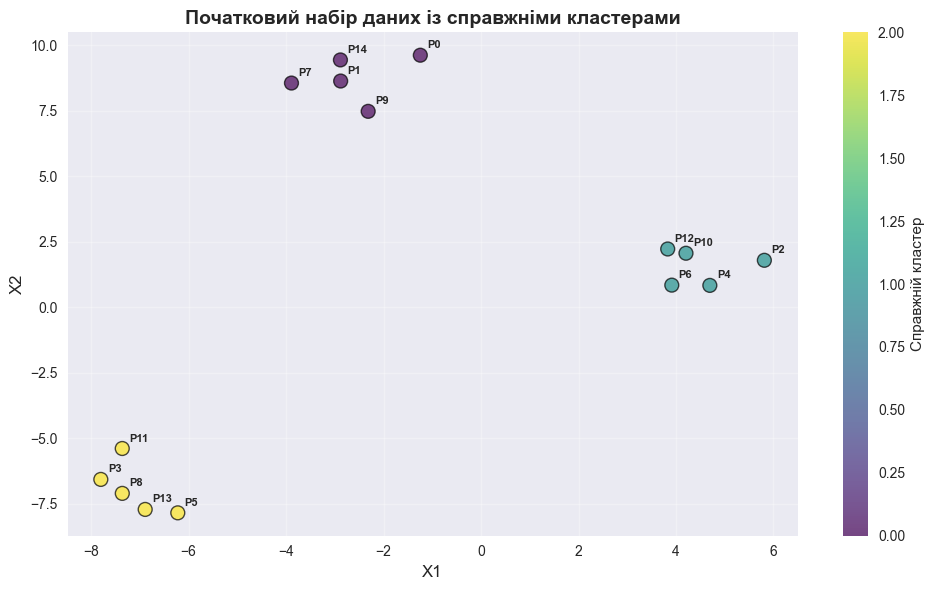

In [3]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', 
                     s=100, alpha=0.7, edgecolors='black', linewidth=1)

for i, (x, y) in enumerate(X):
    plt.annotate(f'P{i}', (x, y), xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')

plt.title('Початковий набір даних із справжніми кластерами', fontsize=14, fontweight='bold')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.colorbar(scatter, label='Справжній кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

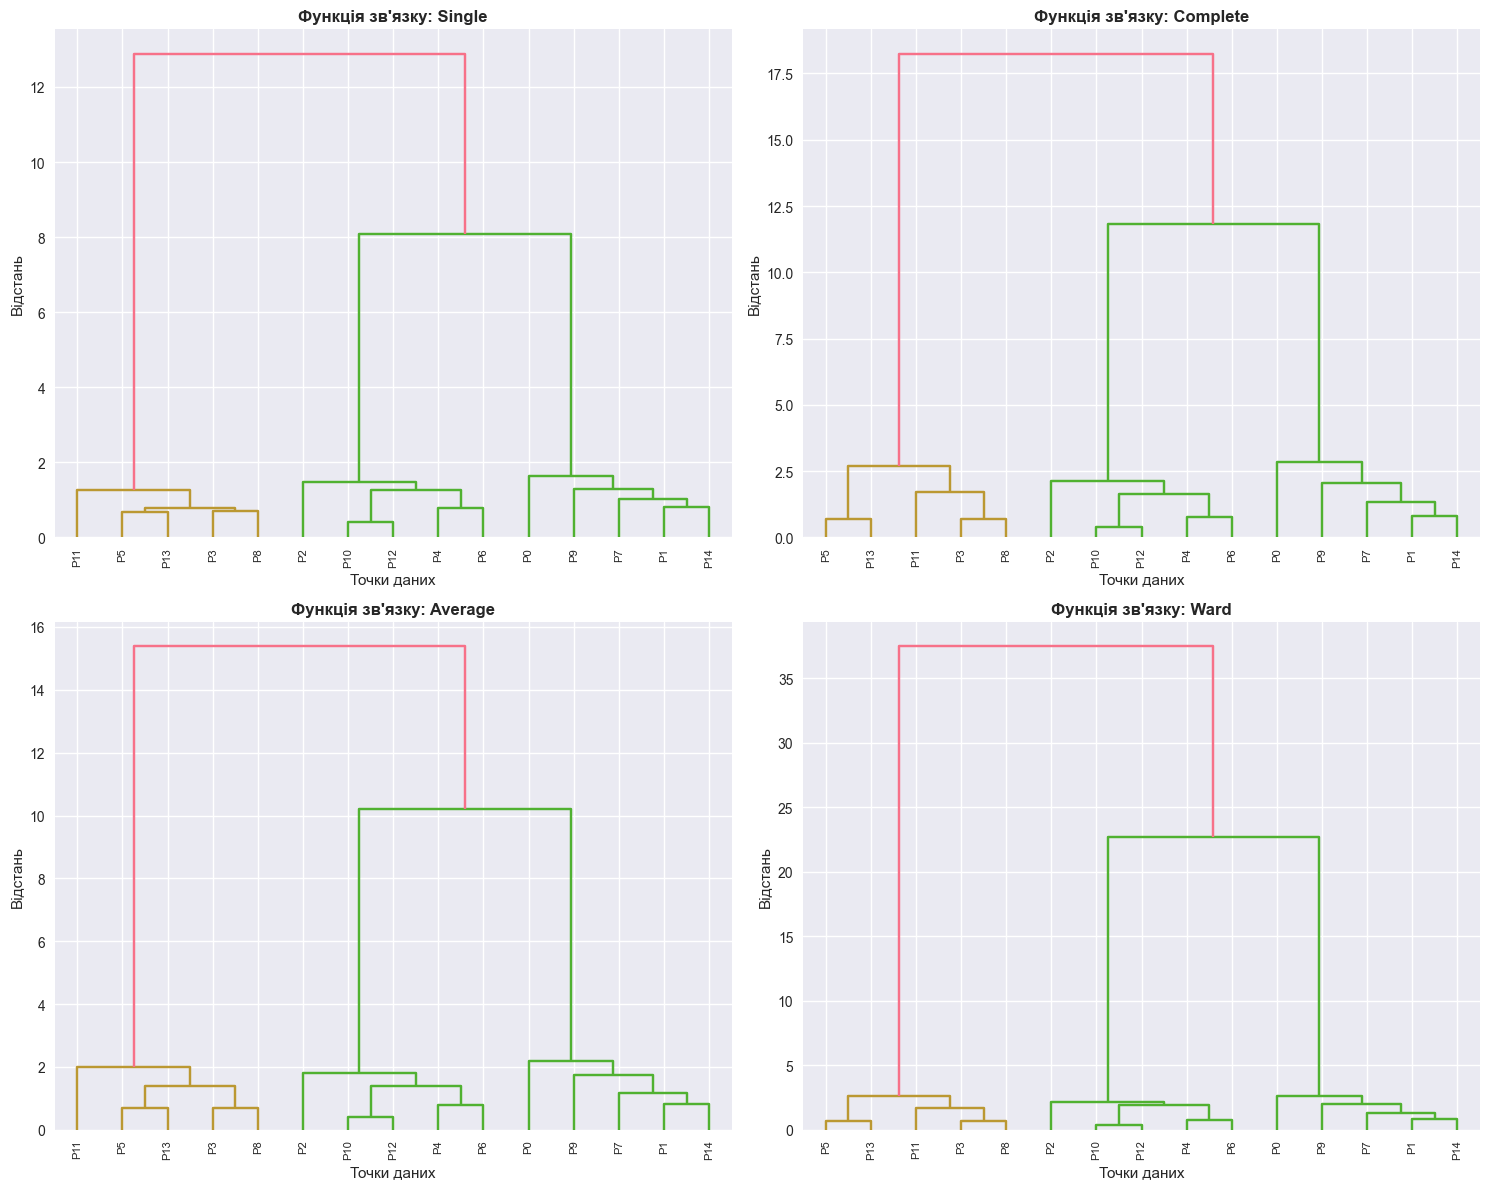

In [4]:
# Порівнюємо різні функції зв'язку
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, method in enumerate(linkage_methods):
    linkage_matrix = linkage(X, method=method)
    
    dendrogram(linkage_matrix, ax=axes[i], 
              labels=[f'P{i}' for i in range(len(X))],
              leaf_rotation=90, leaf_font_size=8)
    
    axes[i].set_title(f'Функція зв\'язку: {method.title()}', fontweight='bold')
    axes[i].set_xlabel('Точки даних')
    axes[i].set_ylabel('Відстань')

plt.tight_layout()
plt.show()

In [5]:
print("Детальний аналіз із використанням середнього зв'язку (average linkage)")
print("=" * 50)

linkage_matrix = linkage(X, method='average')

print("\nМатриця об'єднань (перші 10 злиттів):")
print("Формат: [точка1, точка2, відстань, розмір кластера]")
print(linkage_matrix[:10])

print(f"\nПроцес кластеризації:")
print(f"Починаємо з {len(X)} окремих точок")
print(f"Закінчуємо 1 кластером, який містить усі точки")
print(f"Загальна кількість злиттів: {len(linkage_matrix)}")

for i in range(min(5, len(linkage_matrix))):
    merge = linkage_matrix[i]
    point1, point2, distance, size = merge
    print(f"Злиття {i+1}: Точки {int(point1)} та {int(point2)} на відстані {distance:.3f} (новий розмір кластера: {int(size)})")

Детальний аналіз із використанням середнього зв'язку (average linkage)

Матриця об'єднань (перші 10 злиттів):
Формат: [точка1, точка2, відстань, розмір кластера]
[[10.         12.          0.40853678  2.        ]
 [ 5.         13.          0.68144728  2.        ]
 [ 3.          8.          0.69203573  2.        ]
 [ 4.          6.          0.78050532  2.        ]
 [ 1.         14.          0.80664639  2.        ]
 [ 7.         19.          1.17502464  3.        ]
 [15.         18.          1.39922325  4.        ]
 [16.         17.          1.40663218  4.        ]
 [ 9.         20.          1.74753319  4.        ]
 [ 2.         21.          1.81403748  5.        ]]

Процес кластеризації:
Починаємо з 15 окремих точок
Закінчуємо 1 кластером, який містить усі точки
Загальна кількість злиттів: 14
Злиття 1: Точки 10 та 12 на відстані 0.409 (новий розмір кластера: 2)
Злиття 2: Точки 5 та 13 на відстані 0.681 (новий розмір кластера: 2)
Злиття 3: Точки 3 та 8 на відстані 0.692 (новий розмір кла

## Розрізання дендрограм для формування кластерів

### Як розрізати дендрограму

Після того, як дендрограма побудована, ми можемо "розрізати" її на різних рівнях, щоб отримати різну кількість кластерів. Висота розрізу визначає, скільки кластерів ми отримаємо.

In [6]:
print("Різні способи розрізання дендрограми")
print("=" * 50)

clusters_3 = fcluster(linkage_matrix, 3, criterion='maxclust')
print(f"\nМетод 1: Фіксована кількість кластерів (k=3)")
print(f"Призначення кластерів: {clusters_3}")

distances = linkage_matrix[:, 2]
print(f"\nМетод 2: Розріз за різними порогами відстані")
print(f"Доступні відстані: {distances[:5]}...")

for threshold in [0.5, 1.0, 1.5, 2.0]:
    clusters_thresh = fcluster(linkage_matrix, threshold, criterion='distance')
    n_clusters = len(np.unique(clusters_thresh))
    print(f"Поріг {threshold}: {n_clusters} кластерів")

print(f"\nМетод 3: Аналіз найбільшого розриву")
if len(distances) > 1:
    gaps = np.diff(distances)
    largest_gap_idx = np.argmax(gaps)
    print(f"Найбільший розрив при об'єднанні {largest_gap_idx + 1}")
    print(f"Розмір розриву: {gaps[largest_gap_idx]:.3f}")
    print(f"Відстань до розриву: {distances[largest_gap_idx]:.3f}")
    print(f"Відстань після розриву: {distances[largest_gap_idx + 1]:.3f}")

Різні способи розрізання дендрограми

Метод 1: Фіксована кількість кластерів (k=3)
Призначення кластерів: [3 3 2 1 2 1 2 3 1 3 2 1 2 1 3]

Метод 2: Розріз за різними порогами відстані
Доступні відстані: [0.40853678 0.68144728 0.69203573 0.78050532 0.80664639]...
Поріг 0.5: 14 кластерів
Поріг 1.0: 10 кластерів
Поріг 1.5: 7 кластерів
Поріг 2.0: 5 кластерів

Метод 3: Аналіз найбільшого розриву
Найбільший розрив при об'єднанні 12
Розмір розриву: 7.999
Відстань до розриву: 2.201
Відстань після розриву: 10.200


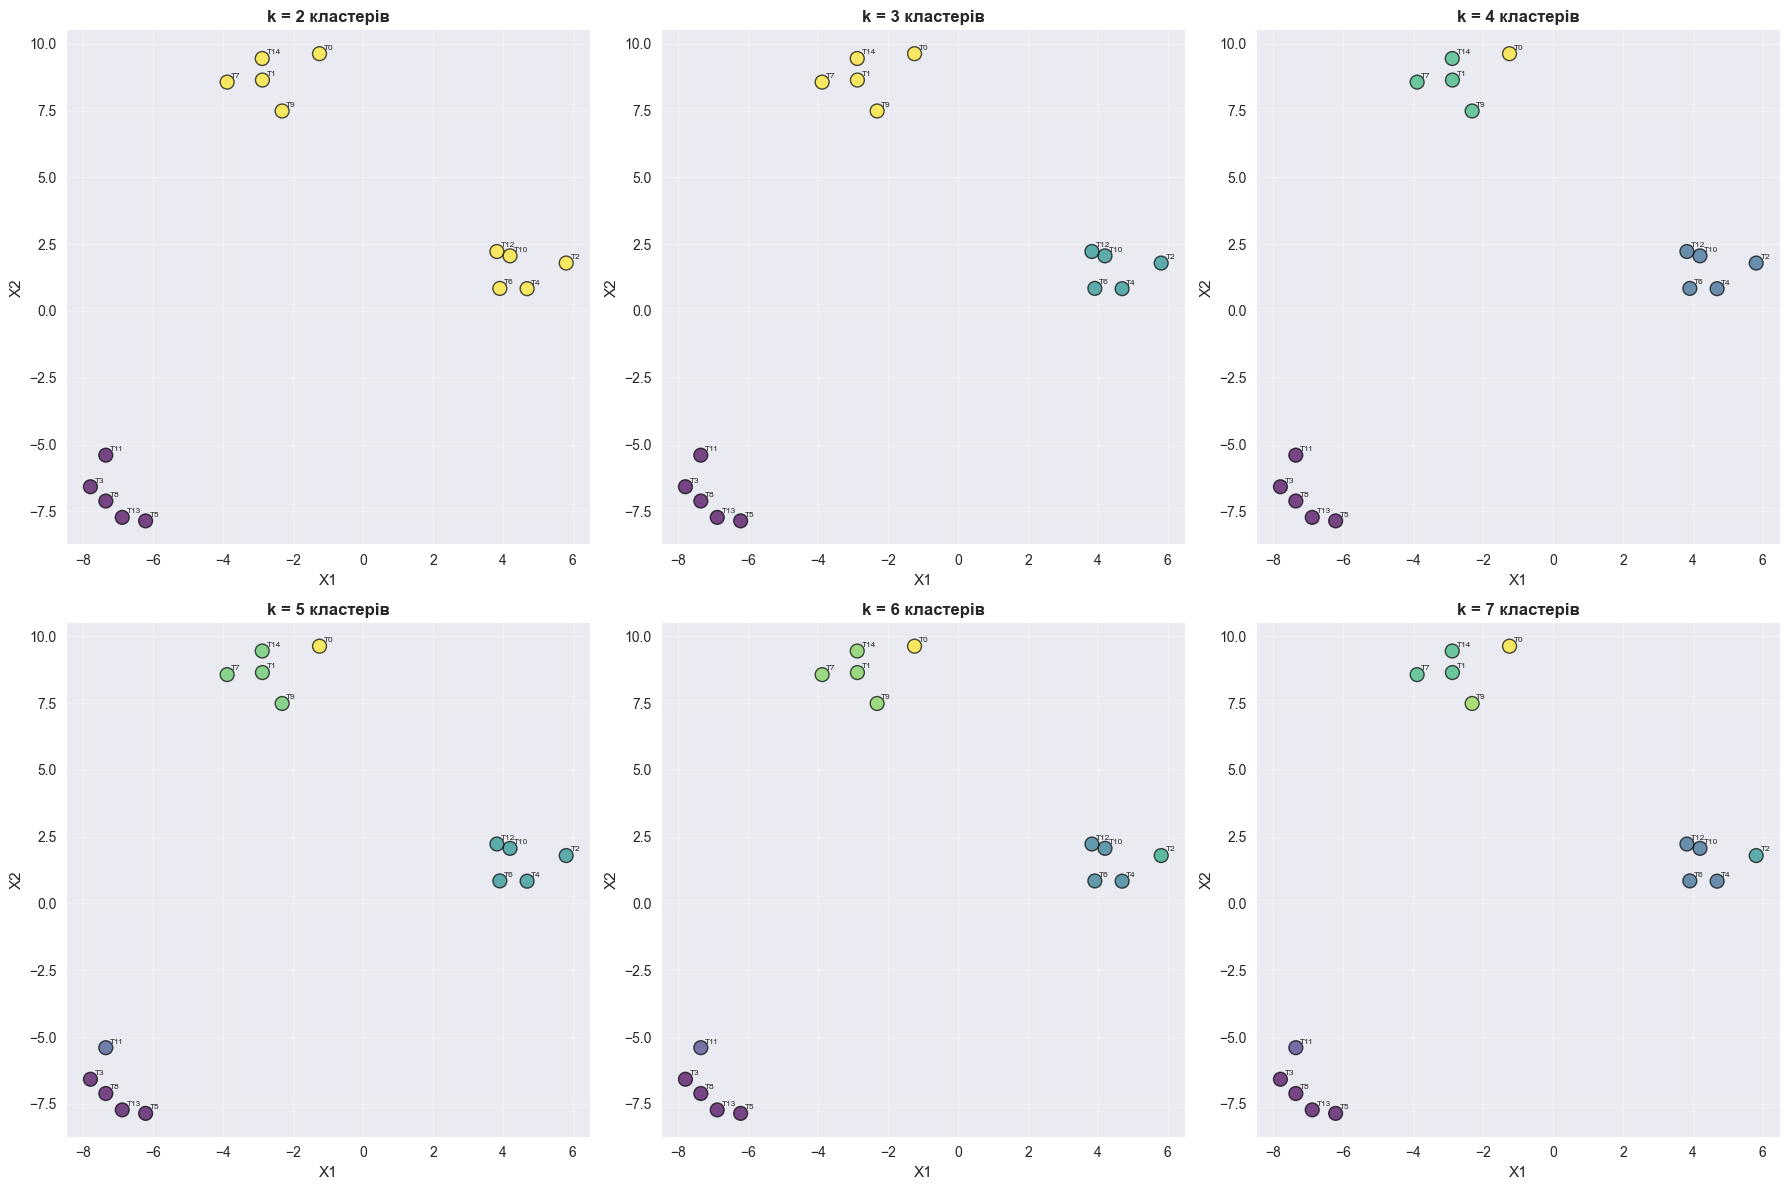

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

n_clusters_list = [2, 3, 4, 5, 6, 7]

for i, n_clusters in enumerate(n_clusters_list):
    row = i // 3
    col = i % 3
    
    clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    
    scatter = axes[row, col].scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', 
                                   s=100, alpha=0.7, edgecolors='black', linewidth=1)
    
    for j, (x, y) in enumerate(X):
        axes[row, col].annotate(f'Т{j}', (x, y), xytext=(3, 3), 
                               textcoords='offset points', fontsize=6)
    
    axes[row, col].set_title(f'k = {n_clusters} кластерів', fontweight='bold')
    axes[row, col].set_xlabel('X1')
    axes[row, col].set_ylabel('X2')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Вибір кількості кластерів

### Методи визначення оптимального k

#### 1. Візуальний огляд дендрограми
- Шукати великі вертикальні відстані між гілками
- Точки з великими відстанями вказують на природні розділення
- Суб'єктивний, але часто ефективний

#### 2. Метод ліктя
- Побудувати графік висоти злиття проти кількості кластерів
- Шукати точку "ліктя", де швидкість зміни сповільнюється
- Подібно до методу ліктя в k-means

#### 3. Силуетний аналіз
- Обчислити силуетний бал для різних значень k
- Вибрати k з найвищим силуетним балом
- Об'єктивний метод оцінки якості кластерів

#### 4. Предметні знання
- Використовувати розуміння проблеми
- Враховувати бізнес-вимоги
- Може бути найкращим методом для конкретних застосувань

Метод ліктя для ієрархічної кластеризації
k = 2: WCSS = 273.40
k = 3: WCSS = 16.50
k = 4: WCSS = 13.10
k = 5: WCSS = 10.08
k = 6: WCSS = 7.82
k = 7: WCSS = 5.74


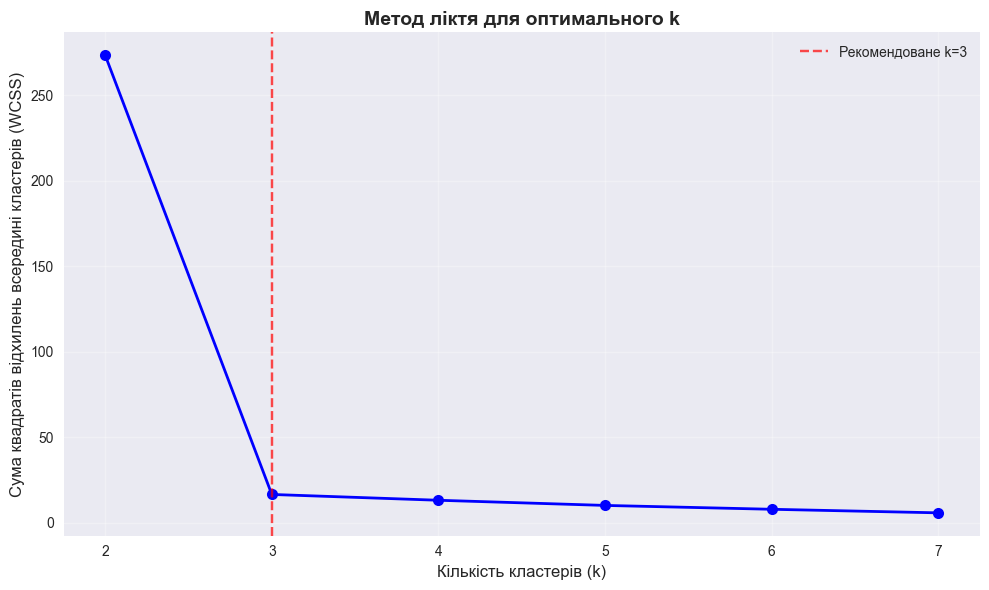

In [8]:
print("Метод ліктя для ієрархічної кластеризації")
print("=" * 50)

k_range = range(2, 8)
wcss_values = []

for k in k_range:
    clusters = fcluster(linkage_matrix, k, criterion='maxclust')
    wcss = 0
    for cluster_id in np.unique(clusters):
        cluster_points = X[clusters == cluster_id]
        if len(cluster_points) > 0:
            centroid = np.mean(cluster_points, axis=0)
            wcss += np.sum((cluster_points - centroid) ** 2)
    wcss_values.append(wcss)
    print(f"k = {k}: WCSS = {wcss:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Кількість кластерів (k)', fontsize=12)
plt.ylabel('Сума квадратів відхилень всередині кластерів (WCSS)', fontsize=12)
plt.title('Метод ліктя для оптимального k', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Рекомендоване k=3')
plt.legend()
plt.tight_layout()
plt.show()

Силуетний аналіз
k = 2: Оцінка силуету = 0.690
k = 3: Оцінка силуету = 0.862
k = 4: Оцінка силуету = 0.677
k = 5: Оцінка силуету = 0.475
k = 6: Оцінка силуету = 0.285
k = 7: Оцінка силуету = 0.261


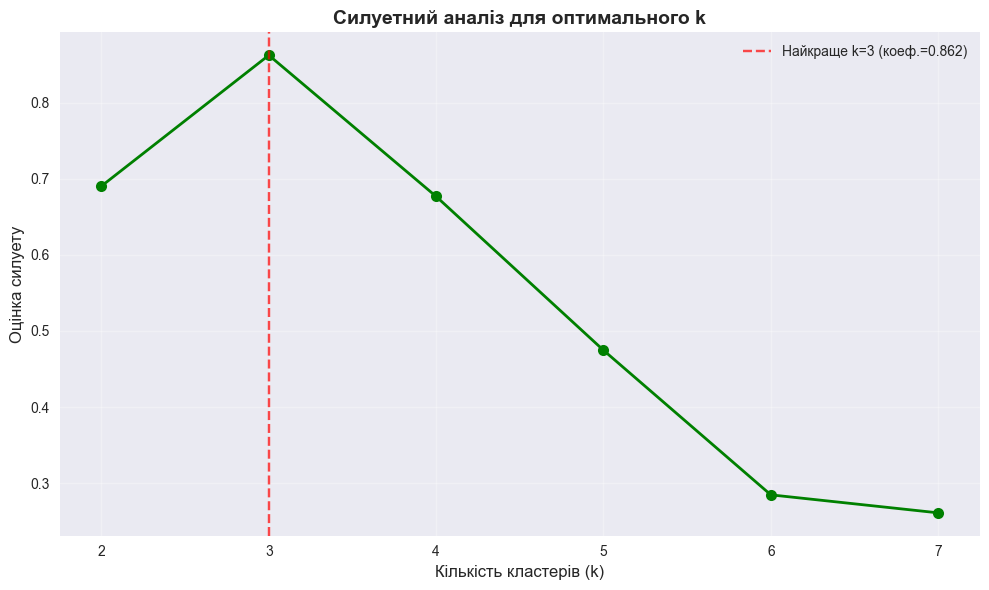


Найкраще k згідно силуетного аналізу: 3
Оцінка силуету: 0.862


In [9]:
from sklearn.metrics import silhouette_score

print("Силуетний аналіз")
print("=" * 30)

silhouette_scores = []

for k in k_range:
    clusters = fcluster(linkage_matrix, k, criterion='maxclust')
    silhouette_avg = silhouette_score(X, clusters)
    silhouette_scores.append(silhouette_avg)
    print(f"k = {k}: Оцінка силуету = {silhouette_avg:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Кількість кластерів (k)', fontsize=12)
plt.ylabel('Оцінка силуету', fontsize=12)
plt.title('Силуетний аналіз для оптимального k', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

best_k = k_range[np.argmax(silhouette_scores)]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, 
           label=f'Найкраще k={best_k} (коеф.={max(silhouette_scores):.3f})')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nНайкраще k згідно силуетного аналізу: {best_k}")
print(f"Оцінка силуету: {max(silhouette_scores):.3f}")

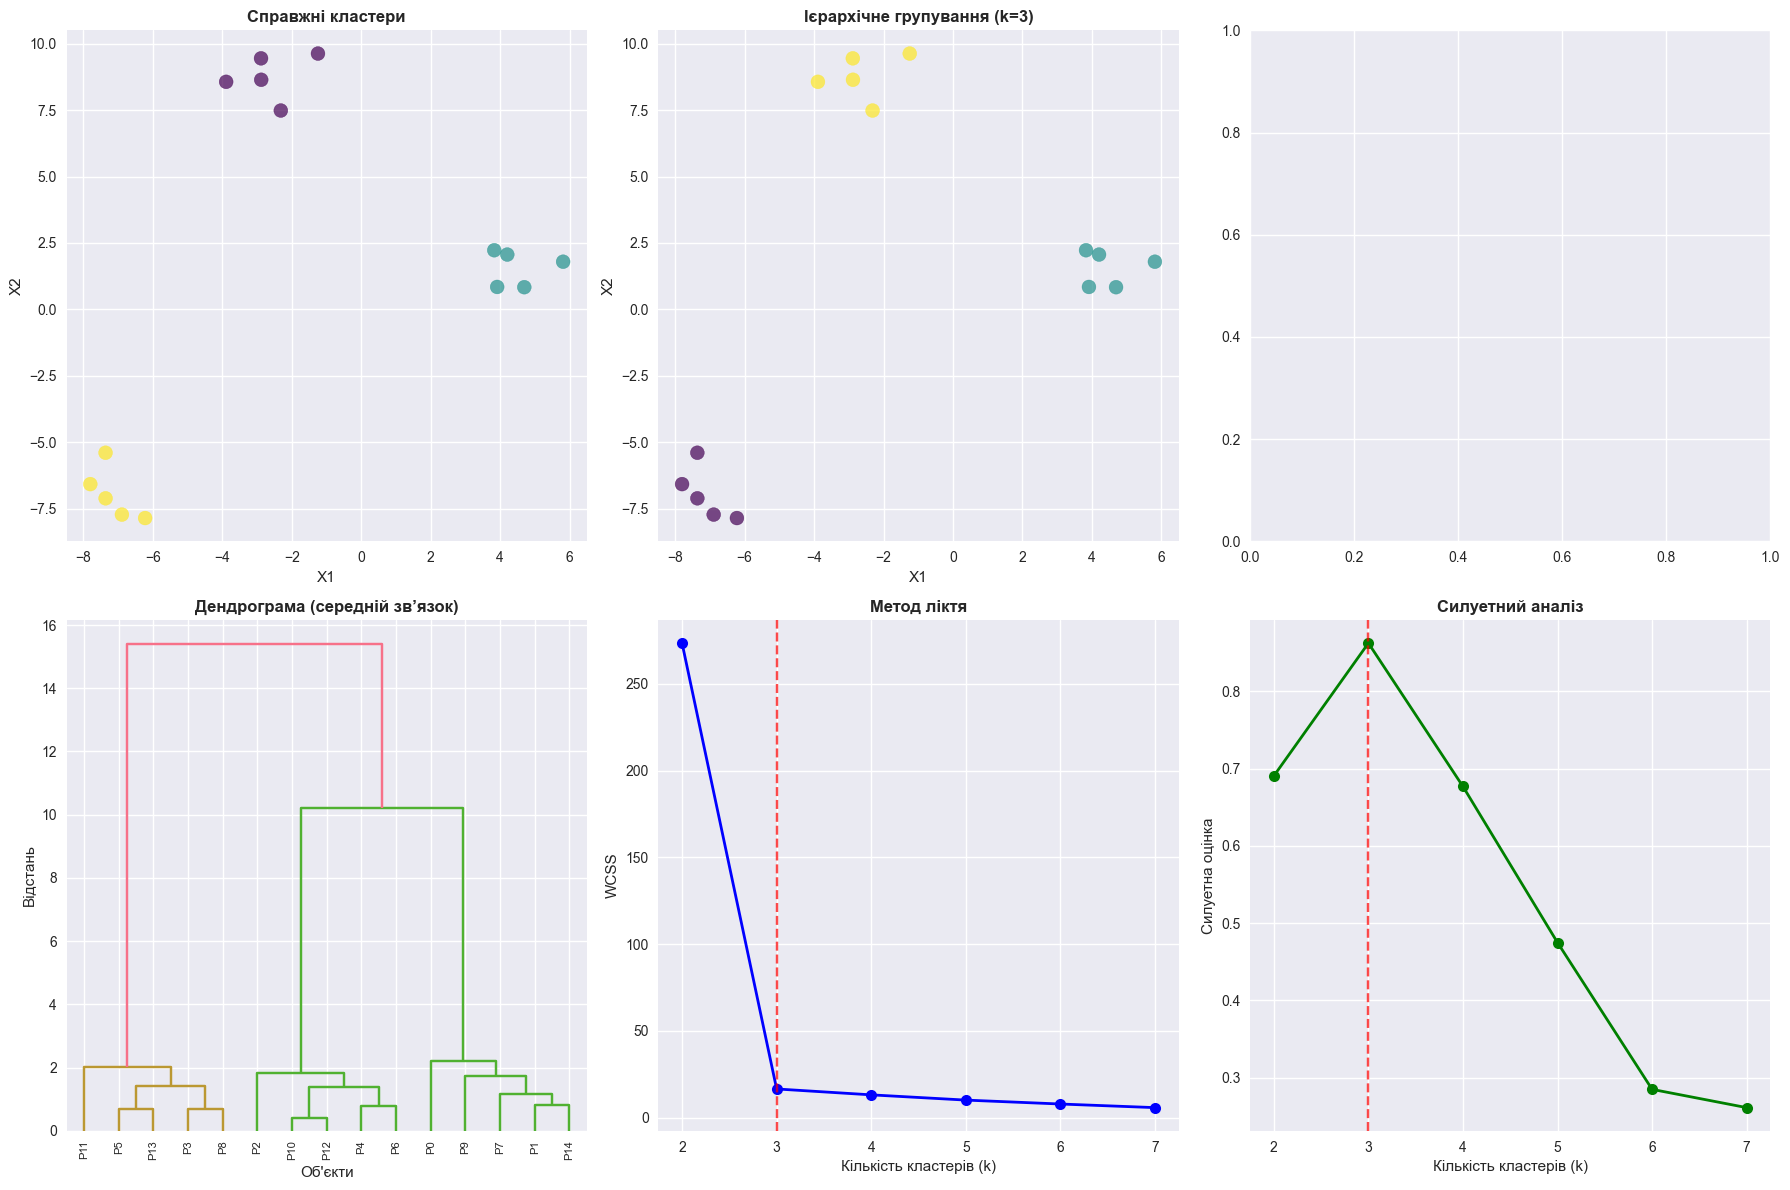

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', s=100, alpha=0.7)
axes[0, 0].set_title('Справжні кластери', fontweight='bold')
axes[0, 0].set_xlabel('X1')
axes[0, 0].set_ylabel('X2')

hierarchical_clusters = fcluster(linkage_matrix, 3, criterion='maxclust')
axes[0, 1].scatter(X[:, 0], X[:, 1], c=hierarchical_clusters, cmap='viridis', s=100, alpha=0.7)
axes[0, 1].set_title('Ієрархічне групування (k=3)', fontweight='bold')
axes[0, 1].set_xlabel('X1')
axes[0, 1].set_ylabel('X2')

dendrogram(linkage_matrix, ax=axes[1, 0], labels=[f'P{i}' for i in range(len(X))],
          leaf_rotation=90, leaf_font_size=8)
axes[1, 0].set_title('Дендрограма (середній зв’язок)', fontweight='bold')
axes[1, 0].set_xlabel('Об\'єкти')
axes[1, 0].set_ylabel('Відстань')

axes[1, 1].plot(k_range, wcss_values, 'bo-', linewidth=2, markersize=8)
axes[1, 1].set_title('Метод ліктя', fontweight='bold')
axes[1, 1].set_xlabel('Кількість кластерів (k)')
axes[1, 1].set_ylabel('WCSS')
axes[1, 1].axvline(x=3, color='red', linestyle='--', alpha=0.7)

axes[1, 2].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1, 2].set_title('Силуетний аналіз', fontweight='bold')
axes[1, 2].set_xlabel('Кількість кластерів (k)')
axes[1, 2].set_ylabel('Силуетна оцінка')
axes[1, 2].axvline(x=best_k, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()